In [56]:
#Blessing Anoroh
# Assignment 8/ week 8 - Assignment High Frequency Words
#DATA 620 - Web Analytics
# March 30, 2026 (Due)


#Instructions
#Instructions
#1. Choose a corpus of interest.
#2. How many total unique words are in the corpus?  (Please feel free to define unique words in any interesting, defensible way).
#3. Taking the most common words, how many unique words represent half of the total words in the corpus?
#4. Identify the 200 highest frequency words in this corpus.
#5. Create a graph that shows the relative frequency of these 200 words.
#6. Does the observed relative frequency of these words follow Zipf’s law?  Explain.
#7. In what ways do you think the frequency of the words in this corpus differ from “all words in all corpora.”


**Introduction:**

In this analysis (assignment), I analyzed a Twitter sentiment dataset from Kaggle to study word frequency patterns in real-world text. The goal was to understand how often words appear, identify the most common words, and explore whether the data follows Zipf’s Law. Cleaning and analyzing the tweets helps reveal how language is used in social media.

Source: https://www.kaggle.com/datasets/yasserh/twitter-tweets-sentiment-dataset

In [57]:
# Install kagglehub to import file directly from Kagglehub
!pip install -q kagglehub

# Imports
import kagglehub
import os
import pandas as pd
import re
from collections import Counter
import matplotlib.pyplot as plt

# latest version of dataset
path = kagglehub.dataset_download("yasserh/twitter-tweets-sentiment-dataset")

print("Path to dataset files:", path)
print("Files in dataset folder:", os.listdir(path))

Using Colab cache for faster access to the 'twitter-tweets-sentiment-dataset' dataset.
Path to dataset files: /kaggle/input/twitter-tweets-sentiment-dataset
Files in dataset folder: ['Tweets.csv']


In [58]:
# Find the CSV file of the sentiment
csv_files = [f for f in os.listdir(path) if f.endswith(".csv")]

if not csv_files:
    raise FileNotFoundError("No CSV file found in the downloaded dataset folder.")

csv_path = os.path.join(path, csv_files[0])
print("Using file:", csv_path)

# Load dataset
df = pd.read_csv(csv_path)

# Preview of dataframe
print(df.head())
print(df.columns)
print(df.shape)

Using file: /kaggle/input/twitter-tweets-sentiment-dataset/Tweets.csv
       textID                                               text  \
0  cb774db0d1                I`d have responded, if I were going   
1  549e992a42      Sooo SAD I will miss you here in San Diego!!!   
2  088c60f138                          my boss is bullying me...   
3  9642c003ef                     what interview! leave me alone   
4  358bd9e861   Sons of ****, why couldn`t they put them on t...   

                         selected_text sentiment  
0  I`d have responded, if I were going   neutral  
1                             Sooo SAD  negative  
2                          bullying me  negative  
3                       leave me alone  negative  
4                        Sons of ****,  negative  
Index(['textID', 'text', 'selected_text', 'sentiment'], dtype='object')
(27481, 4)


In [59]:
# Select the tweet text column directly
text_col = "text"   # this dataset uses "text" for tweets

print("Text column being used:", text_col)

Text column being used: text


In [60]:
# Basic cleaning
df = df.dropna(subset=[text_col]).copy()    # remove rows with missing tweet text
df[text_col] = df[text_col].astype(str)     # make sure all text are strings

def clean_tweet(text):
    text = text.lower()                     # convert to lowercase
    text = re.sub(r"[^a-z\s]", "", text)    # remove everything except letters
    return text                             # return cleaned text

df["clean_text"] = df[text_col].apply(clean_tweet)
df = df[df["clean_text"] != ""].copy()

print("Shape after cleaning:", df.shape)
df[[text_col, "clean_text"]].head()

Shape after cleaning: (27480, 5)


,text,clean_text
0,"I`d have responded, if I were going",id have responded if i were going
1,Sooo SAD I will miss you here in San Diego!!!,sooo sad i will miss you here in san diego
2,my boss is bullying me...,my boss is bullying me
3,what interview! leave me alone,what interview leave me alone
4,"Sons of ****, why couldn`t they put them on t...",sons of why couldnt they put them on the rel...


In [61]:
# Build corpus: combining all cleaned tweets into one text for analysis
corpus = " ".join(df["clean_text"])
words = corpus.split()

print("Total words in corpus:", len(words))
print("Sample words:", words[:20])

Total words in corpus: 345022
Sample words: ['id', 'have', 'responded', 'if', 'i', 'were', 'going', 'sooo', 'sad', 'i', 'will', 'miss', 'you', 'here', 'in', 'san', 'diego', 'my', 'boss', 'is']


In [62]:
# Question 2: total unique words
unique_words = set(words)
num_unique_words = len(unique_words)

print("Total unique words in the corpus:", num_unique_words)

Total unique words in the corpus: 27914


In this analysis, I define unique words as lowercase words made up of letters only, after cleaning the text by removing punctuation, links, and special characters. This helps make sure that words like “Happy” and “happy” are counted as the same word.I also remove links. This way, the word counts are more consistent and easier to understand.

In [63]:
# Question 3: number of unique words making up half the corpus

word_counts = Counter(words)    # count how many times each word appears
total_words = sum(word_counts.values())  # total number of words in the corpus

sorted_words = word_counts.most_common() # list of words sorted from most to least frequent

cumulative_count = 0
num_words_half = 0

for word, count in sorted_words:
    cumulative_count += count
    num_words_half += 1
    if cumulative_count >= total_words / 2:
        break

print("Number of unique words needed to account for half of the corpus:", num_words_half)


Number of unique words needed to account for half of the corpus: 100


*The result shows that the top 100 most frequent words make up half of all the words in the dataset.*



In [64]:
# Question 4: top 200 words
top_200 = word_counts.most_common(200)

top_200_df = pd.DataFrame(top_200, columns=["Word", "Frequency"])
top_200_df["Relative Frequency"] = top_200_df["Frequency"] / total_words

top_200_df

,Word,Frequency,Relative Frequency
0,i,13179,0.038198
1,to,10015,0.029027
2,the,8985,0.026042
3,a,6714,0.019460
4,my,5512,0.015976
...,...,...,...
195,life,249,0.000722
196,ur,249,0.000722
197,guys,247,0.000716
198,doesnt,244,0.000707


This table shows the most frequent words in the corpus. For example at the very top of 200 most frequent words, the word “i” appears 13,179 times, which makes up about 3.82% of all words. Similarly, the word “to” appears 10,015 times, or about 2.90% of the corpus. These results show that a small number of common words make up a large portion of the text.

 Words near the bottom, like “doesnt” and “already,” appear much less often and make up a very small part of the total words (less than 0.1%).This shows how quickly word frequency drops as we move down the list, with only a few words appearing very often and most words appearing much less frequently.



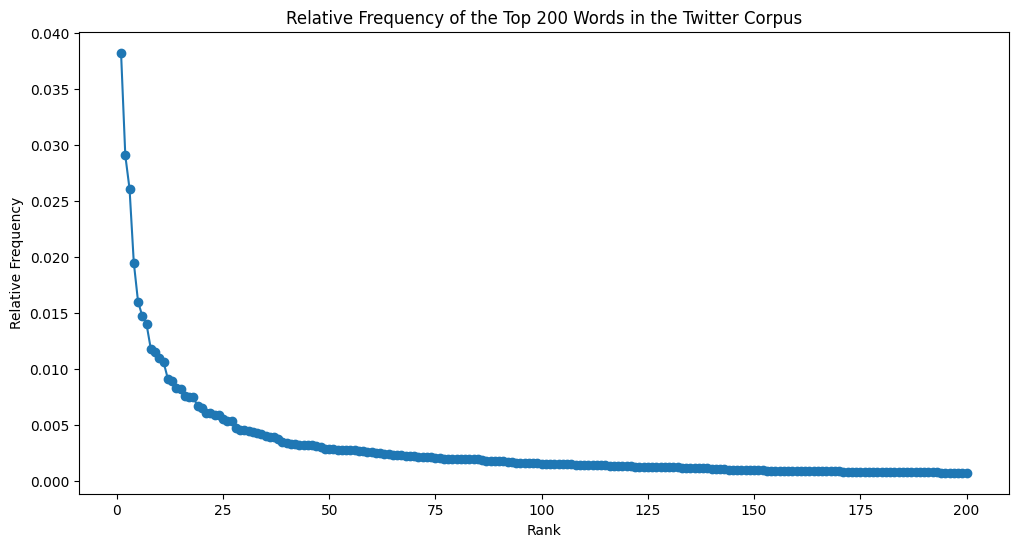

In [65]:
# Question 5: graph of relative frequency
plt.figure(figsize=(12,6))
plt.plot(range(1, 201), top_200_df["Relative Frequency"], marker="o")
plt.xlabel("Rank")
plt.ylabel("Relative Frequency")
plt.title("Relative Frequency of the Top 200 Words in the Twitter Corpus")
plt.show()

The graph shows that the most common words have much higher relative frequency, and then the values drop quickly as the rank increases. After the first few words, the line levels out, showing that most words appear much less often. This pattern shows that a small number of words are used very frequently, while most words are used rarely.



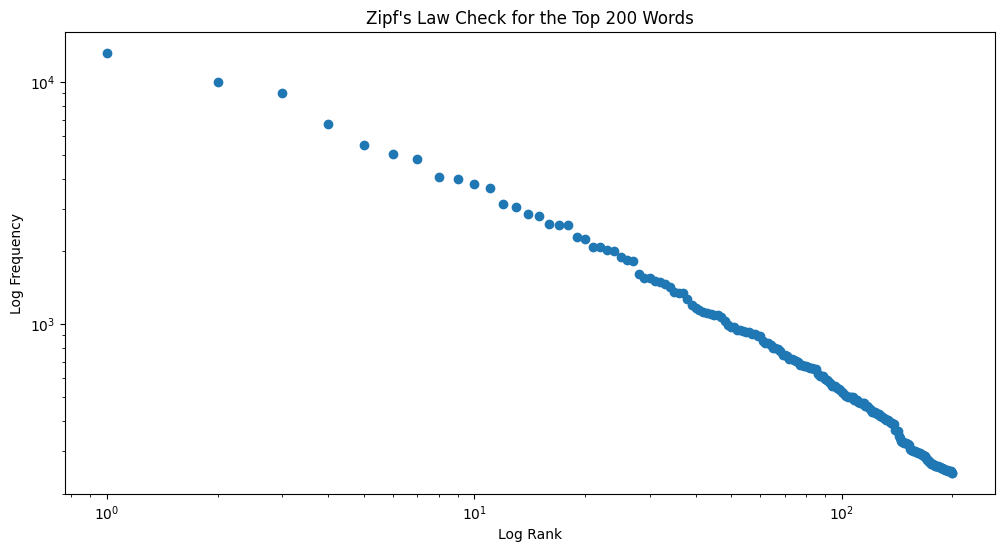

In [66]:
# Question 6: Does the observed relative frequency follow Zipf’s Law? Explain.
#check Zipf's law with log-log plot
plt.figure(figsize=(12,6))
plt.loglog(range(1, 201), top_200_df["Frequency"], marker="o", linestyle="none")
plt.xlabel("Log Rank")
plt.ylabel("Log Frequency")
plt.title("Zipf's Law Check for the Top 200 Words")
plt.show()

The graph shows a clear downward pattern, which means the word frequencies generally follow Zipf’s Law. As the rank increases, the frequency decreases, and as the frequency increases, the rank decreases. This matches what Zipf’s Law describes. This shows that a few words are used a lot, while most words are used less often.




*Question 7: How does this corpus differ from all words in all corpora?*

The word frequencies in this Twitter corpus differ from other corpora because tweets are short and informal. They often include simple language, slang, and repeated words, while larger corpora tend to have more formal and diverse vocabulary.

**Conclusion**

In conclusion, this analysis showed that word usage in the Twitter dataset is not evenly distributed. A small number of common words appear very frequently, while most words appear only a few times. The graphs also showed a pattern consistent with Zipf’s Law, where frequency decreases as rank increases. Overall, this highlights how language tends to rely heavily on a small set of common words, especially in informal text like tweets.